Zadanie: Zaimplementuj krzyżowanie PMX (opisane tu: https://en.wikipedia.org/wiki/Crossover_(genetic_algorithm)#Crossover_for_permutations ). Porównaj czas działania i jakość rozwiązania z krzyżowaniem opartym o inwersje zaimplementowanym poniżej oraz z podejściem opartym o MIP (`tsp_lazy_constraints.ipynb`) na losowych grafach o 20, 40 i 80 wierzchołkach. Zbierz wyniki w tabelkę. Wypróbuj różną liczebność populacji oraz metody wyboru potomstwa.


In [3]:
using Evolutionary
using Random
using Plots

function generate_distance_matrix(n; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]
    return X, Y, d
end

n = 40
X, Y, d = generate_distance_matrix(n)

([9.913970137863682, 70.19797138879542, 50.3261785841856, 87.58412053070398, 95.34654118744876, 50.7810571056071, 78.97511635624403, 7.125413261100788, 13.837807897217225, 39.31891799217675  …  23.14349506594935, 82.85299084095385, 81.21218274251633, 30.033561741521254, 24.424204661921078, 77.19544356189549, 84.26218370481618, 81.76189015392971, 87.51478186309849, 87.22121647535855], [47.07715605583087, 45.74787799446105, 39.31968187864505, 95.05129878297356, 78.35752622358207, 64.99869009136225, 13.167067492229867, 12.318877197601253, 19.319307029658294, 92.85029082227491  …  50.36021954489278, 54.34886273358863, 21.275144999693786, 88.42487976012477, 81.93602590407201, 35.084318413318606, 17.858107530782274, 3.1023219989021467, 7.67753298108198, 21.514711709923716], [0.0 60.29865493513747 … 87.02997345080387 81.42388407109866; 60.29865493513747 0.0 … 41.82371449836383 29.614814222804647; … ; 87.02997345080387 41.82371449836383 … 0.0 13.84029247562309; 81.42388407109866 29.61481422280

In [4]:
# Permutation inversion

function perm_to_inv(perm::Vector)
    N = length(perm)
    inv = zeros(Int, N)
    for i in 1:N
        m = 1
        while perm[m] != i
            if perm[m] > i
                inv[i] += 1
            end
            m += 1
        end
    end
    return inv
end

function inv_to_perm(inv::Vector)
    N = length(inv)
    pos = zeros(Int, N)
    for i in N:-1:1
        for m in (i+1):N
            if pos[m] >= inv[i] + 1
                pos[m] += 1
            end
        end
        pos[i] = inv[i] + 1
    end
    perm = zeros(Int, N)
    for i in 1:N
        perm[pos[i]] = i
    end
    return perm
end

RP = randperm(20)
iRP = perm_to_inv(RP)
println(RP == inv_to_perm(iRP))


true


In [5]:
function has_subtour(perm::Vector)
    c = 1
    for i in 1:(length(perm)-1)
        c = perm[c]
        if c == 1
            return true
        end
    end
    return false
end

has_subtour (generic function with 1 method)

In [6]:
function mutate_swap(recombinant::AbstractVector;
    rng::AbstractRNG=Random.default_rng())
    N = length(recombinant)
    a = true
    while a || has_subtour(recombinant)
        i = rand(rng, 1:N)
        j = rand(rng, 1:N)
        v = recombinant[i]
        recombinant[i] = recombinant[j]
        recombinant[j] = v
        a = false
    end
    return recombinant
end


"""

Implementation follows "Genetic Algorithm Solution of the TSP Avoiding Special Crossover and Mutation"
"""
function recombine_tsp(v1::T, v2::T; rng::AbstractRNG=Random.default_rng()) where {T <: AbstractVector}
    N = length(v1)
    i1 = perm_to_inv(v1)
    i2 = perm_to_inv(v2)
    crossover_point = rand(2:(N-1))
    i1c = vcat(i1[1:crossover_point], i2[(crossover_point+1):N])
    i2c = vcat(i2[1:crossover_point], i1[(crossover_point+1):N])
    return inv_to_perm(i1c), inv_to_perm(i2c)
end

recombine_tsp

In [7]:
x0 = [mod1(i+1, n) for i in 1:n]
function cost(x)
    dist = 0.0
    for i in 1:length(x)
        dist += d[i, x[i]]
    end
    if has_subtour(x)
        dist += 5000
    end
    return dist
end
println("Initial cost: $(cost(x0))")
x0

Initial cost: 1959.8478236534881


40-element Vector{Int64}:
  2
  3
  4
  5
  6
  7
  8
  9
 10
 11
  ⋮
 33
 34
 35
 36
 37
 38
 39
 40
  1

In [8]:

x_sol = Evolutionary.optimize(
    cost,
    x0,
    GA(; populationSize=10000, crossover=recombine_tsp, mutation=mutate_swap, epsilon=0.01, crossoverRate=0.9),
    Evolutionary.Options(; iterations=10000)
)
println(has_subtour(x_sol.minimizer))
println(x_sol)


false

 * Status: success

 * Candidate solution
    Minimizer:  [26, 27, 19,  ...]
    Minimum:    932.7009157479584
    Iterations: 216

 * Found with
    Algorithm: GA[P=10000,x=0.9,μ=0.1,ɛ=0.01]

 * Convergence measures
    |f(x) - f(x')| = 0.0 ≤ 1.0e-12

 * Work counters
    Seconds run:   9.855 (vs limit Inf)
    Iterations:    216
    f(x) calls:    2170000



[26, 27, 19, 24, 4, 18, 2, 1, 8, 35, 34, 3, 5, 23, 12, 28, 13, 17, 9, 11, 16, 29, 7, 25, 15, 30, 6, 33, 36, 31, 20, 21, 37, 10, 22, 32, 38, 39, 40, 14]


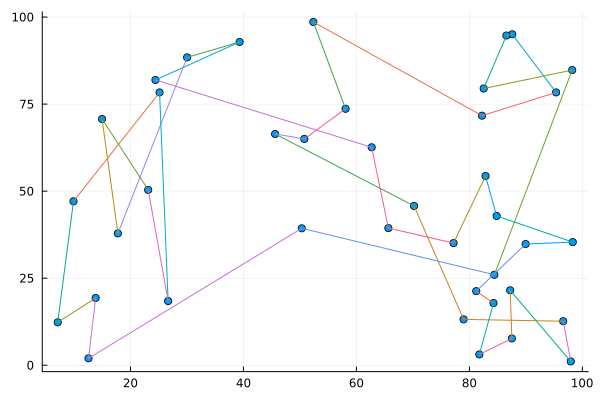

In [9]:
println(x_sol.minimizer)
function plot_tour(X, Y, x)
    plot = Plots.plot()
    scatter!(X, Y)
    for i in 1:length(x)
        j = x[i]
        Plots.plot!(plot, [X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour(X, Y, x_sol.minimizer)